# Online Retail Analysis: From Customer Purchase Behavior to Churn Prediction


## Introduction
This project analyzes transactional data from an online retail dataset to explore customer purchase behavior and sales patterns.

The analysis includes revenue trends, time-based patterns, and customer-level insights to better understand how customers interact with the business.


## Objective
Understand customer behavior and use these insights to identify customers who are likely to churn.


## Scope
- Data cleaning and preparation  
- Feature engineering at customer level (recency, frequency, monetary, revenue)  
- Customer segmentation based on value  
- Exploratory analysis of sales patterns and customer behavior  
- Time-based split to define churn  
- Logistic regression model as a baseline approach  
- Model evaluation and threshold analysis


## 1. Data Understanding

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_ = pd.read_csv("dataset csv online retail 2.csv")
df_

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.0000000,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.0000000,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00.0000000,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00.0000000,4.95,12680.0,France


In [3]:
df_.shape

(541910, 8)

In [4]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer_ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
for col in df_.columns:
    print(f"{col}: {df_[col].dtype}")

Invoice: object
StockCode: object
Description: object
Quantity: int64
InvoiceDate: object
Price: float64
Customer_ID: float64
Country: object


In [6]:
df_.describe([0.05,0.1,0.5,0.75,0.90,0.95,0.99]).T

,count,mean,std,min,5%,10%,50%,75%,90%,95%,99%,max
Quantity,541910.0,9.552234,218.080957,-80995.00,1.00,1.00,3.00,10.00,24.00,29.00,100.0,80995.0
Price,541910.0,4.611138,96.759765,-11062.06,0.42,0.63,2.08,4.13,7.95,9.95,18.0,38970.0
Customer_ID,406830.0,15287.684160,1713.603074,12346.00,12626.00,12876.00,15152.00,16791.00,17719.00,17905.00,18212.0,18287.0


In [7]:
df_.describe(include='O').T

,count,unique,top,freq
Invoice,541910,25900,573585,1114
StockCode,541910,4070,85123A,2313
Description,540456,4221,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541910,23260,2011-10-31 14:41:00.0000000,1114
Country,541910,38,United Kingdom,495478


In [8]:
df_.nunique()

Invoice        25900
StockCode       4070
Description     4221
Quantity         722
InvoiceDate    23260
Price           1630
Customer_ID     4372
Country           38
dtype: int64

The dataset contains over 500,000 transactions, indicating a large retail dataset.

There are significant missing values in Customer_ID, which impacts customer-level analysis.

The data is highly skewed, with extreme values in quantity and price, suggesting the presence of outliers.

## 2. Data Preparation

In [9]:
df_.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer_ID    135080
Country             0
dtype: int64

In [10]:
df_[df_['Customer_ID'].isnull()]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00.0000000,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00.0000000,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00.0000000,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00.0000000,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00.0000000,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00.0000000,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00.0000000,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00.0000000,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00.0000000,10.79,NaN,United Kingdom


In [11]:
df_ = df_.dropna(subset=['Customer_ID']).copy()
df_

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.0000000,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.0000000,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00.0000000,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00.0000000,4.95,12680.0,France


In [12]:
df_['Customer_ID'] = df_['Customer_ID'].astype('object')            
print(df_['Customer_ID'].dtype)

object


In [13]:
df_.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406830 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      406830 non-null  object 
 1   StockCode    406830 non-null  object 
 2   Description  406830 non-null  object 
 3   Quantity     406830 non-null  int64  
 4   InvoiceDate  406830 non-null  object 
 5   Price        406830 non-null  float64
 6   Customer_ID  406830 non-null  object 
 7   Country      406830 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 27.9+ MB


In [14]:
duplicate_count = df_.duplicated().sum() 
duplicate_count

5225

In [15]:
df_ = df_.drop_duplicates()
df_

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.0000000,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.0000000,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00.0000000,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00.0000000,4.95,12680.0,France


In [16]:
df_.shape

(401605, 8)

In [17]:
unique_countries = df_['Country'].unique()
unique_countries

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [18]:
unspecified_count = df_[df_['Country'] == 'Unspecified'].shape[0]
unspecified_count

241

In [19]:
df_ = df_[df_['Country'] != 'Unspecified']             

df_.shape[0]

401364

In [20]:
ec_rows = df_[df_['Country'] == 'European Community']
ec_rows

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
168149,551013,22839,3 TIER CAKE TIN GREEN AND CREAM,1,2011-04-26 10:54:00.0000000,14.95,15108.0,European Community
168150,551013,22840,ROUND CAKE TIN VINTAGE RED,2,2011-04-26 10:54:00.0000000,7.95,15108.0,European Community
168151,551013,22841,ROUND CAKE TIN VINTAGE GREEN,2,2011-04-26 10:54:00.0000000,7.95,15108.0,European Community
168152,551013,22457,NATURAL SLATE HEART CHALKBOARD,6,2011-04-26 10:54:00.0000000,2.95,15108.0,European Community
168153,551013,22314,OFFICE MUG WARMER CHOC+BLUE,6,2011-04-26 10:54:00.0000000,2.95,15108.0,European Community
...,...,...,...,...,...,...,...,...
273232,560783,21098,CHRISTMAS TOILET ROLL,12,2011-07-21 10:24:00.0000000,1.25,15108.0,European Community
273233,560783,72807C,SET/3 VANILLA SCENTED CANDLE IN BOX,12,2011-07-21 10:24:00.0000000,4.25,15108.0,European Community
273234,560783,85036B,CHOCOLATE 1 WICK MORRIS BOX CANDLE,12,2011-07-21 10:24:00.0000000,4.25,15108.0,European Community
273235,560783,85035C,ROSE 3 WICK MORRIS BOX CANDLE,8,2011-07-21 10:24:00.0000000,4.25,15108.0,European Community


In [21]:
df_ = df_[df_['Country'] != 'European Community']

In [22]:
df_.shape

(401303, 8)

In [23]:
count_0_or_neg = df_[df_['Price'] <= 0].shape[0]
count_0_or_neg

40

In [24]:
df_ = df_[df_['Price'] > 0]
df_

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.0000000,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.0000000,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00.0000000,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00.0000000,4.95,12680.0,France


In [25]:
quantity_0_or_neg = df_[df_['Quantity'] <= 0].shape[0]
quantity_0_or_neg

8871

In [26]:
quantity_neg = df_[df_['Quantity'] < 0].shape[0]
quantity_neg

8871

In [27]:
df = df_[df_['Quantity'] > 0]
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.0000000,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.0000000,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00.0000000,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00.0000000,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00.0000000,4.95,12680.0,France


In [28]:
df_returns = df_[df_['Quantity'] < 0]                            
df_returns

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00.0000000,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00.0000000,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00.0000000,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00.0000000,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00.0000000,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00.0000000,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00.0000000,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00.0000000,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00.0000000,1.25,17315.0,United Kingdom


In [29]:
df.shape

(392392, 8)

In [30]:
special_codes = ["POST", "C2", "M", "D", "DOT", "BANK CHARGES", "PADS", "M", "S", "B"]

Non_product = df["StockCode"].astype(str).str.upper().isin(special_codes)

df[Non_product]["StockCode"].value_counts()

StockCode
POST            1097
M                279
C2               133
DOT               16
BANK CHARGES      12
PADS               3
Name: count, dtype: int64

In [31]:
df[Non_product].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
45,536370,POST,POSTAGE,3,2010-12-01 08:45:00.0000000,18.00,12583.0,France
386,536403,POST,POSTAGE,1,2010-12-01 11:27:00.0000000,15.00,12791.0,Netherlands
1123,536527,POST,POSTAGE,1,2010-12-01 13:04:00.0000000,18.00,12662.0,Germany
1423,536540,C2,CARRIAGE,1,2010-12-01 14:05:00.0000000,50.00,14911.0,EIRE
2239,536569,M,Manual,1,2010-12-01 15:35:00.0000000,1.25,16274.0,United Kingdom
2250,536569,M,Manual,1,2010-12-01 15:35:00.0000000,18.95,16274.0,United Kingdom
4406,536779,BANK CHARGES,Bank Charges,1,2010-12-02 15:08:00.0000000,15.00,15823.0,United Kingdom
5095,536840,POST,POSTAGE,1,2010-12-02 18:27:00.0000000,18.00,12738.0,Germany
5258,536852,POST,POSTAGE,1,2010-12-03 09:51:00.0000000,18.00,12686.0,France
5325,536858,POST,POSTAGE,2,2010-12-03 10:36:00.0000000,40.00,13520.0,Switzerland


In [32]:
df = df[~df["StockCode"].astype(str).str.upper().isin(special_codes)]

In [33]:
codes_to_remove = [
    "AMAZONFEE","DCGS0003","DCGS0004","DCGS0069",
    "DCGS0070","DCGS0076","DCGSSBOY","DCGSSGIRL",
    "GIFT_0001_10","GIFT_0001_20","GIFT_0001_30",
    "GIFT_0001_40","GIFT_0001_50"
]

df[df["StockCode"].astype(str).str.upper().isin(codes_to_remove)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country


In [34]:
df = df[~df["StockCode"].astype(str).str.upper().isin(codes_to_remove)]

In [35]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00.0000000,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00.0000000,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00.0000000,3.39,17850.0,United Kingdom


In [36]:
df.shape

(390852, 8)

In [37]:
df=df.copy()

In [38]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%Y-%m-%d %H:%M:%S.%f')

In [39]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


- The dataset was cleaned by removing missing Customer_ID values and duplicate records.

- Invalid transactions such as non-positive price and quantity were filtered out, and return-related records were excluded.

- Non-product stock codes and unclear country labels were removed to focus on meaningful sales data.

## 3. Feature Engineering

In [40]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Minute'] = df['InvoiceDate'].dt.minute
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek + 1
df['IsWeekend'] = df['DayOfWeek'].isin([6,7])

In [41]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,26,3,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,26,3,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False


In [42]:
df['DayOfWeek'] .unique()

array([3, 4, 5, 7, 1, 2])

In [43]:
df['Revenue'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,26,3,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,26,3,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34


In [44]:
df.shape

(390852, 16)

In [45]:
def get_quarter_label(month):
    if month in [1, 2, 3]:
        return 'Jan-Mar'
    elif month in [4, 5, 6]:
        return 'Apr-Jun'
    elif month in [7, 8, 9]:
        return 'Jul-Sep'
    else:
        return 'Oct-Dec'

df['Quarter_Year'] = df['Month'].apply(get_quarter_label)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend,Revenue,Quarter_Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,26,3,False,15.30,Oct-Dec
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34,Oct-Dec
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,26,3,False,22.00,Oct-Dec
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34,Oct-Dec
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34,Oct-Dec


In [46]:
def assign_geographic_region(country):
    western_europe = ['United Kingdom', 'Netherlands', 'EIRE', 'Germany', 'France', 'Belgium', 'Switzerland', 'Austria', 'Channel Islands']
    northern_europe = ['Sweden', 'Norway', 'Finland', 'Denmark', 'Iceland']
    southern_europe = ['Spain', 'Portugal', 'Italy', 'Greece', 'Cyprus', 'Malta']
    asia_pacific = ['Australia', 'Japan', 'Singapore']
    north_america = ['USA', 'Canada']
    middle_east = ['United Arab Emirates', 'Lebanon', 'Saudi Arabia', 'Bahrain', 'Israel']
    south_america = ['Brazil']
    africa = ['RSA']
    eastern_europe = ['Poland', 'Lithuania', 'Czech Republic']

    country = country.strip()
    if country in western_europe:
        return 'Western Europe'
    elif country in northern_europe:
        return 'Northern Europe'
    elif country in southern_europe:
        return 'Southern Europe'
    elif country in asia_pacific:
        return 'Asia-Pacific'
    elif country in north_america:
        return 'North America'
    elif country in middle_east:
        return 'Middle East'
    elif country in south_america:
        return 'South America'
    elif country in africa:
        return 'Africa'
    elif country in eastern_europe:
        return 'Eastern Europe'
    else:
        return 'Other'

In [47]:
df['Country_Region'] = df['Country'].apply(assign_geographic_region)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,Day,Hour,Minute,DayOfWeek,IsWeekend,Revenue,Quarter_Year,Country_Region
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,26,3,False,15.30,Oct-Dec,Western Europe
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34,Oct-Dec,Western Europe
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,26,3,False,22.00,Oct-Dec,Western Europe
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34,Oct-Dec,Western Europe
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,26,3,False,20.34,Oct-Dec,Western Europe


In [48]:
df["qty_rank"]   = df["Quantity"].rank(pct=True)
df["price_rank"] = df["Price"].rank(pct=True)

In [49]:
def assign_segment(row):
    if row.qty_rank >= 0.8 and row.price_rank >= 0.8:
        return "A_PremiumVolume"
    elif row.qty_rank >= 0.8 and row.price_rank < 0.4:
        return "B_HighVolumeCheap"
    elif row.qty_rank < 0.4 and row.price_rank >= 0.8:
        return "C_LowVolumePremium"
    elif 0.4 <= row.qty_rank < 0.8:
        return "D_Average"
    else:
        return "E_LowPerformer"

df["segment"] = df.apply(assign_segment, axis=1)

In [50]:
df["segment"].value_counts()

segment
D_Average             172630
E_LowPerformer        115126
C_LowVolumePremium     53959
B_HighVolumeCheap      45616
A_PremiumVolume         3521
Name: count, dtype: int64

In [51]:
df[["qty_rank", "price_rank", "segment"]].head(10)

,qty_rank,price_rank,segment
0,0.540346,0.638419,D_Average
1,0.540346,0.738233,D_Average
2,0.606212,0.654516,D_Average
3,0.540346,0.738233,D_Average
4,0.540346,0.738233,D_Average
5,0.249119,0.916859,C_LowVolumePremium
6,0.540346,0.816328,D_Average
7,0.540346,0.497948,D_Average
8,0.540346,0.497948,D_Average
9,0.540346,0.816328,D_Average


In [52]:
def cap_outliers_iqr(group, col):
    q1 = group[col].quantile(0.25)
    q3 = group[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    group[col + "_capped"] = group[col].clip(lower, upper)
    return group

df = (
    df
    .groupby("segment", group_keys=False)
    .apply(cap_outliers_iqr, col="Revenue")
)

In [53]:
df[["segment", "Revenue", "Revenue_capped"]].head(10)

,segment,Revenue,Revenue_capped
0,D_Average,15.30,15.30
1,D_Average,20.34,20.34
2,D_Average,22.00,22.00
3,D_Average,20.34,20.34
4,D_Average,20.34,20.34
5,C_LowVolumePremium,15.30,15.30
6,D_Average,25.50,25.50
7,D_Average,11.10,11.10
8,D_Average,11.10,11.10
9,D_Average,25.50,25.50


In [54]:
(df["Revenue"] != df["Revenue_capped"]).sum()

37539

In [55]:
changed = (df["Revenue"] != df["Revenue_capped"]).mean()
changed

0.09604402689509073

In [56]:
df.assign(changed = df["Revenue"] != df["Revenue_capped"]) \
  .groupby("segment")["changed"].mean() \
  .sort_values(ascending=False)

segment
E_LowPerformer        0.144563
B_HighVolumeCheap     0.133243
A_PremiumVolume       0.111048
D_Average             0.072612
C_LowVolumePremium    0.035064
Name: changed, dtype: float64

In [57]:
(df["Revenue"].sum() - df["Revenue_capped"].sum())

2992286.785000001

In [58]:
df["cap_diff"] = df["Revenue"] - df["Revenue_capped"]

In [59]:
df["is_capped"] = (df["cap_diff"] > 0).astype(int)

In [60]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,...,IsWeekend,Revenue,Quarter_Year,Country_Region,qty_rank,price_rank,segment,Revenue_capped,cap_diff,is_capped
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,...,False,15.30,Oct-Dec,Western Europe,0.540346,0.638419,D_Average,15.30,0.0,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,False,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,...,False,22.00,Oct-Dec,Western Europe,0.606212,0.654516,D_Average,22.00,0.0,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,False,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,False,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0


In [61]:
df['Price'].describe()

count    390852.000000
mean          2.873960
std           4.285298
min           0.040000
25%           1.250000
50%           1.950000
75%           3.750000
max         649.500000
Name: Price, dtype: float64

In [62]:
count_price_less_1 = df[df['Price'] < 1].shape[0]            
print("Price < 1 row count:", count_price_less_1)

Price < 1 row count: 91505


In [63]:
count_price_less_0_5 = df[df['Price'] < 0.5].shape[0]           
print("Price < 0.5 row count:", count_price_less_0_5)

Price < 0.5 row count: 38885


In [64]:
low_price_products_sorted = df[df['Price'] < 0.5].sort_values(by='Price')

low_price_products_sorted.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,...,IsWeekend,Revenue,Quarter_Year,Country_Region,qty_rank,price_rank,segment,Revenue_capped,cap_diff,is_capped
277498,561113,16045,POPART WOODEN PENCILS ASST,200,2011-07-25 12:09:00,0.04,17841.0,United Kingdom,2011,7,...,False,8.0,Jul-Sep,Western Europe,0.995111,0.000086,B_HighVolumeCheap,8.0,0.0,0
427789,573399,16045,POPART WOODEN PENCILS ASST,100,2011-10-30 15:35:00,0.04,13949.0,United Kingdom,2011,10,...,True,4.0,Oct-Dec,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
434040,574025,16045,POPART WOODEN PENCILS ASST,100,2011-11-02 12:26:00,0.04,12748.0,United Kingdom,2011,11,...,False,4.0,Oct-Dec,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
276441,561047,16045,POPART WOODEN PENCILS ASST,900,2011-07-24 12:46:00,0.04,16948.0,United Kingdom,2011,7,...,True,36.0,Jul-Sep,Western Europe,0.999662,0.000086,B_HighVolumeCheap,36.0,0.0,0
382404,569900,16045,POPART WOODEN PENCILS ASST,100,2011-10-06 16:17:00,0.04,17651.0,United Kingdom,2011,10,...,False,4.0,Oct-Dec,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0


In [65]:
df_sorted_by_price = df.sort_values(by='Price', ascending=False)

df_sorted_by_price.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,...,IsWeekend,Revenue,Quarter_Year,Country_Region,qty_rank,price_rank,segment,Revenue_capped,cap_diff,is_capped
222671,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.5,15098.0,United Kingdom,2011,6,...,False,38970.0,Apr-Jun,Western Europe,0.971380,0.999999,A_PremiumVolume,441.000,38529.000,1
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.5,15098.0,United Kingdom,2011,6,...,False,649.5,Apr-Jun,Western Europe,0.088063,0.999999,C_LowVolumePremium,29.075,620.425,1
118748,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-14 11:38:00,295.0,13452.0,United Kingdom,2011,3,...,False,295.0,Jan-Mar,Western Europe,0.088063,0.999986,C_LowVolumePremium,29.075,265.925,1
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-02 18:06:00,295.0,13145.0,United Kingdom,2010,12,...,False,295.0,Oct-Dec,Western Europe,0.088063,0.999986,C_LowVolumePremium,29.075,265.925,1
134007,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-03-25 14:19:00,295.0,13452.0,United Kingdom,2011,3,...,False,295.0,Jan-Mar,Western Europe,0.088063,0.999986,C_LowVolumePremium,29.075,265.925,1
205759,554836,22655,VINTAGE RED KITCHEN CABINET,1,2011-05-26 16:25:00,295.0,13015.0,United Kingdom,2011,5,...,False,295.0,Apr-Jun,Western Europe,0.088063,0.999986,C_LowVolumePremium,29.075,265.925,1
51636,540647,22655,VINTAGE RED KITCHEN CABINET,1,2011-01-10 14:57:00,295.0,17406.0,United Kingdom,2011,1,...,False,295.0,Jan-Mar,Western Europe,0.088063,0.999986,C_LowVolumePremium,29.075,265.925,1
82768,543253,22655,VINTAGE RED KITCHEN CABINET,1,2011-02-04 15:32:00,295.0,14842.0,United Kingdom,2011,2,...,False,295.0,Jan-Mar,Western Europe,0.088063,0.999986,C_LowVolumePremium,29.075,265.925,1
171178,551393,22656,VINTAGE BLUE KITCHEN CABINET,1,2011-04-28 12:22:00,295.0,14973.0,United Kingdom,2011,4,...,False,295.0,Apr-Jun,Western Europe,0.088063,0.999986,C_LowVolumePremium,29.075,265.925,1
32484,539080,22655,VINTAGE RED KITCHEN CABINET,1,2010-12-16 08:41:00,295.0,16607.0,United Kingdom,2010,12,...,False,295.0,Oct-Dec,Western Europe,0.088063,0.999986,C_LowVolumePremium,29.075,265.925,1


In [66]:
df_sorted_by_price_asc = df.sort_values(by='Price', ascending=True)

df_sorted_by_price_asc.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,...,IsWeekend,Revenue,Quarter_Year,Country_Region,qty_rank,price_rank,segment,Revenue_capped,cap_diff,is_capped
468553,576513,16045,POPART WOODEN PENCILS ASST,100,2011-11-15 12:10:00,0.04,14715.0,United Kingdom,2011,11,...,False,4.0,Oct-Dec,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
217066,555876,16045,POPART WOODEN PENCILS ASST,100,2011-06-07 15:28:00,0.04,15799.0,United Kingdom,2011,6,...,False,4.0,Apr-Jun,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
506043,579124,16045,POPART WOODEN PENCILS ASST,100,2011-11-28 12:14:00,0.04,15721.0,United Kingdom,2011,11,...,False,4.0,Oct-Dec,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
334170,566233,16045,POPART WOODEN PENCILS ASST,100,2011-09-11 11:04:00,0.04,12635.0,Germany,2011,9,...,True,4.0,Jul-Sep,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
387159,570269,16045,POPART WOODEN PENCILS ASST,100,2011-10-10 10:16:00,0.04,17227.0,United Kingdom,2011,10,...,False,4.0,Oct-Dec,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
293771,562616,16045,POPART WOODEN PENCILS ASST,100,2011-08-08 12:28:00,0.04,14748.0,United Kingdom,2011,8,...,False,4.0,Jul-Sep,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
267502,560300,16045,POPART WOODEN PENCILS ASST,100,2011-07-18 10:29:00,0.04,14911.0,EIRE,2011,7,...,False,4.0,Jul-Sep,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
525404,580619,16045,POPART WOODEN PENCILS ASST,100,2011-12-05 12:08:00,0.04,15053.0,United Kingdom,2011,12,...,False,4.0,Oct-Dec,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
233804,557492,16045,POPART WOODEN PENCILS ASST,100,2011-06-20 15:08:00,0.04,13717.0,United Kingdom,2011,6,...,False,4.0,Apr-Jun,Western Europe,0.985803,0.000086,B_HighVolumeCheap,4.0,0.0,0
221726,556267,16045,POPART WOODEN PENCILS ASST,500,2011-06-09 19:33:00,0.04,13694.0,United Kingdom,2011,6,...,False,20.0,Apr-Jun,Western Europe,0.998939,0.000086,B_HighVolumeCheap,20.0,0.0,0


In [67]:
df_sorted = df.sort_values(by='Revenue', ascending=False)

df_sorted.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,...,IsWeekend,Revenue,Quarter_Year,Country_Region,qty_rank,price_rank,segment,Revenue_capped,cap_diff,is_capped
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,2011,12,...,False,168469.60,Oct-Dec,Western Europe,1.000000,0.550862,E_LowPerformer,12.275,168457.325,1
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,2011,1,...,False,77183.60,Jan-Mar,Western Europe,0.999997,0.234627,B_HighVolumeCheap,59.250,77124.350,1
222671,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,2011,6,...,False,38970.00,Apr-Jun,Western Europe,0.971380,0.999999,A_PremiumVolume,441.000,38529.000,1
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,2011,9,...,False,7144.72,Jul-Sep,Western Europe,0.999867,0.873749,A_PremiumVolume,441.000,6703.720,1
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,2011,1,...,False,6539.40,Jan-Mar,Western Europe,0.999983,0.592342,E_LowPerformer,12.275,6527.125,1


- Time-based (year, month, weekday) and revenue-related features were created to capture sales behavior. Product segmentation and revenue capping were applied to reduce the impact of extreme values and support more stable analysis.

## 4. Sales Analysis

In [68]:
print(df['Price'].describe())

count    390852.000000
mean          2.873960
std           4.285298
min           0.040000
25%           1.250000
50%           1.950000
75%           3.750000
max         649.500000
Name: Price, dtype: float64


In [69]:
print("Price Mean:", df['Price'].mean())
print("Price Median:", df['Price'].median())                                     
print("Price Mode:", df['Price'].mode()[0])

Price Mean: 2.8739599643854965
Price Median: 1.95
Price Mode: 1.25


In [70]:
print("Quantity Mean:", df['Quantity'].mean())                                  
print("Quantity Median:", df['Quantity'].median())
print("Quantity Mode:", df['Quantity'].mode()[0])

Quantity Mean: 13.149501601629261
Quantity Median: 6.0
Quantity Mode: 1


In [71]:
print("Revenue Mean:", df['Revenue'].mean())
print("Revenue Median:", df['Revenue'].median())
print("Revenue Mode:", df['Revenue'].mode()[0])

Revenue Mean: 22.344538648900354
Revenue Median: 11.9
Revenue Mode: 15.0


          Quantity     Price   Revenue
Quantity  1.000000 -0.019928  0.916927
Price    -0.019928  1.000000  0.068321
Revenue   0.916927  0.068321  1.000000


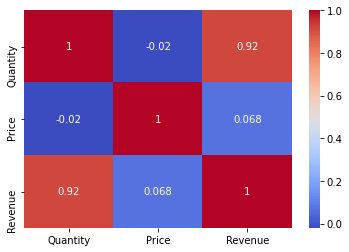

In [72]:
corr = df[['Quantity', 'Price', 'Revenue']].corr()
print(corr)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

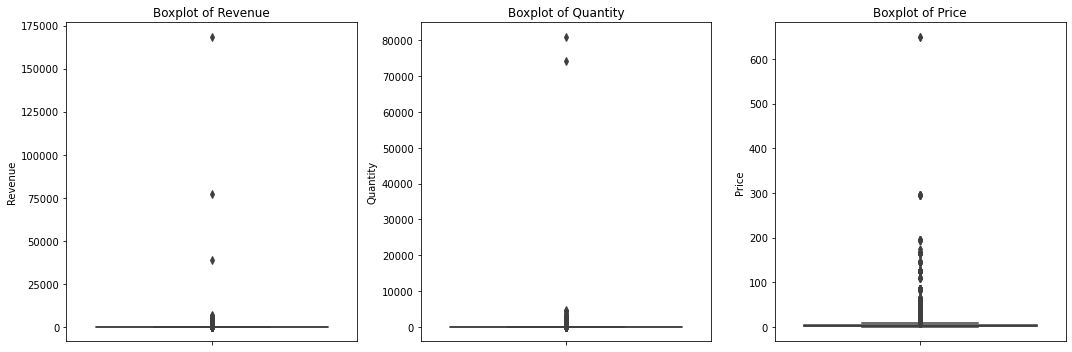

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Revenue', 'Quantity', 'Price']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

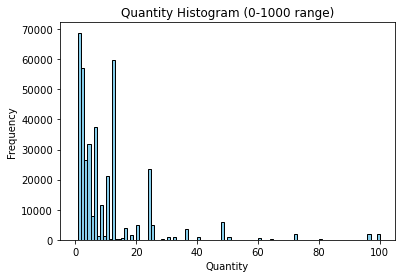

In [74]:
plt.hist(df['Quantity'], bins=100, range=(0, 100), color='skyblue', edgecolor='black')
plt.title('Quantity Histogram (0-1000 range)')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

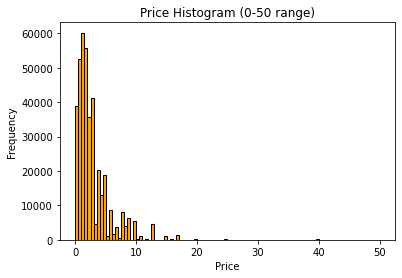

In [75]:
plt.hist(df['Price'], bins=100, range=(0, 50), color='orange', edgecolor='black')
plt.title('Price Histogram (0-50 range)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

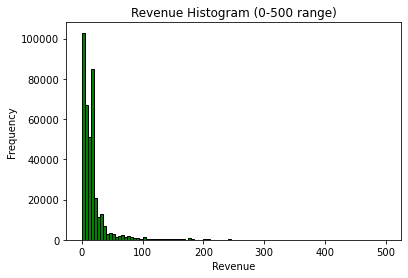

In [76]:
plt.hist(df['Revenue'], bins=100, range=(0, 500), color='green', edgecolor='black')
plt.title('Revenue Histogram (0-500 range)')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

In [77]:
total_revenue = df['Revenue'].sum()                                        
print(f"Total Revenue: {total_revenue}")

Total Revenue: 8733407.620000001


In [78]:
df[['Quantity', 'Price']].describe()

,Quantity,Price
count,390852.000000,390852.000000
mean,13.149502,2.873960
std,180.876529,4.285298
min,1.000000,0.040000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,649.500000


In [79]:
min_price = df.nsmallest(10, 'Price')[['Price', 'Quantity']]
print("Lowest 10 price values:")
print(min_price)

max_price = df.nlargest(10, 'Price')[['Price', 'Quantity']]
print("\nHighest 10 price values:")
print(max_price)

min_quantity = df.nsmallest(10, 'Quantity')[['Quantity', 'Price']]
print("\nLowest 10 quantity values:")
print(min_quantity)

max_quantity = df.nlargest(10, 'Quantity')[['Quantity', 'Price']]
print("\nHighest 10 quantity values:")
print(max_quantity)

Lowest 10 price values:
        Price  Quantity
217066   0.04       100
221726   0.04       500
228959   0.04       100
229052   0.04       100
229498   0.04       100
233804   0.04       100
235392   0.04       100
243015   0.04       100
255649   0.04       100
257109   0.04       100

Highest 10 price values:
        Price  Quantity
222671  649.5        60
222682  649.5         1
4989    295.0         1
32484   295.0         1
51636   295.0         1
82768   295.0         1
118748  295.0         1
134007  295.0         1
171178  295.0         1
205759  295.0         1

Lowest 10 quantity values:
     Quantity  Price
113         1   1.25
114         1   0.85
115         1   2.55
118         1   1.95
120         1   2.95
121         1   2.95
123         1   2.95
127         1   0.85
128         1   0.85
129         1   1.45

Highest 10 quantity values:
        Quantity  Price
540421     80995   2.08
61619      74215   1.04
421632      4800   0.21
206121      4300   0.72
97432       39

In [80]:
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: {total_revenue}")

Total Revenue: 8733407.620000001


In [81]:
total_Quantity = df['Quantity'].sum()
print(f"Total Quantity: {total_Quantity}")

Total Quantity: 5139509


In [82]:
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products_qty)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35241
PACK OF 72 RETROSPOT CAKE CASES       33646
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [83]:
top_products_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products_revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142239.25
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56375.85
RABBIT NIGHT LIGHT                     51251.24
CHILLI LIGHTS                          46265.11
PAPER CHAIN KIT 50'S CHRISTMAS         42584.13
Name: Revenue, dtype: float64

In [84]:
top_products = df.groupby('Description').agg(
    total_quantity=('Quantity', 'sum'),
    average_price=('Price', 'mean')
).sort_values(by='total_quantity', ascending=False).head(10)

print("Top 10 products by quantity and average price:")
print(top_products)

Top 10 products by quantity and average price:
                                    total_quantity  average_price
Description                                                      
PAPER CRAFT , LITTLE BIRDIE                  80995       2.080000
MEDIUM CERAMIC TOP STORAGE JAR               77916       1.220303
WORLD WAR 2 GLIDERS ASSTD DESIGNS            54319       0.292606
JUMBO BAG RED RETROSPOT                      46078       2.015969
WHITE HANGING HEART T-LIGHT HOLDER           36706       2.892768
ASSORTED COLOUR BIRD ORNAMENT                35241       1.680690
PACK OF 72 RETROSPOT CAKE CASES              33646       0.548179
POPCORN HOLDER                               30919       0.843231
RABBIT NIGHT LIGHT                           27153       2.012770
MINI PAINT SET VINTAGE                       26076       0.656523


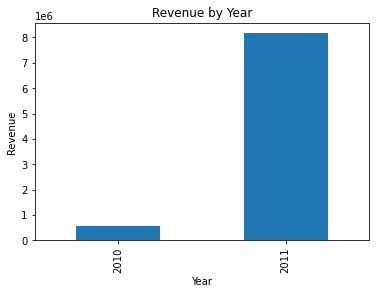

In [85]:
annual_sales = df.groupby('Year')['Revenue'].sum()
annual_sales.plot(kind='bar')
plt.title('Revenue by Year')
plt.ylabel('Revenue')
plt.show()

In [86]:
product_sales = df.groupby(['StockCode', 'Description'])['Quantity'].sum().reset_index()

top_selling_products = product_sales.sort_values(by='Quantity', ascending=False)

top_selling_products

,StockCode,Description,Quantity
2600,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
2098,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
3018,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
3442,85099B,JUMBO BAG RED RETROSPOT,46078
3457,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706
...,...,...,...
3698,90104,PURPLE FRANGIPANI HAIRCLIP,1
3107,84551,CROCHET DOG KEYRING,1
3106,84550,CROCHET LILAC/RED BEAR KEYRING,1
493,21310,CAPIZ CHANDELIER,1


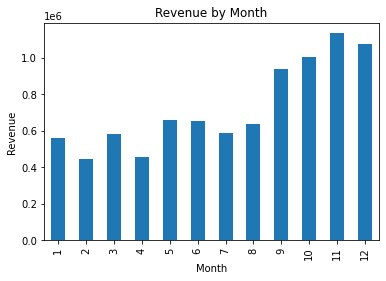

In [87]:
annual_sales = df.groupby('Month')['Revenue'].sum()
annual_sales.plot(kind='bar')
plt.title('Revenue by Month')
plt.ylabel('Revenue')
plt.show()

In [88]:
country_sales = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_sales

Country
United Kingdom          7242855.32
Netherlands              283889.34
EIRE                     257013.12
Germany                  205381.15
France                   183801.94
Australia                138103.81
Spain                     55706.56
Switzerland               52441.95
Japan                     37416.37
Belgium                   36927.34
Sweden                    36828.83
Norway                    32454.64
Portugal                  26643.90
Channel Islands           19997.54
Finland                   18344.88
Denmark                   18211.34
Italy                     15820.24
Cyprus                    13167.16
Singapore                  9120.39
Austria                    8742.68
Israel                     7215.84
Poland                     6974.65
Greece                     4425.52
Iceland                    4310.00
USA                        3580.39
Canada                     3115.44
Malta                      2070.59
United Arab Emirates       1864.78
Lebanon     

In [89]:
orders_by_month = df.groupby('Month')['Invoice'].nunique()
orders_by_year = df.groupby('Year')['Invoice'].nunique()

print("Order Count by Month:\n", orders_by_month)
print("Order Count by Year:\n", orders_by_year)

Order Count by Month:
 Month
1      983
2      992
3     1312
4     1137
5     1543
6     1388
7     1317
8     1265
9     1739
10    1903
11    2642
12    2170
Name: Invoice, dtype: int64
Order Count by Year:
 Year
2010     1394
2011    16997
Name: Invoice, dtype: int64


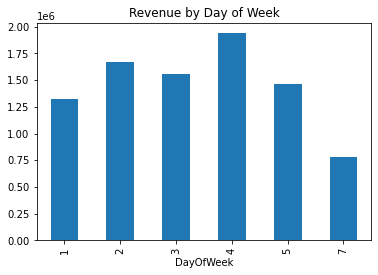

IsWeekend
False    7954055.87
True      779351.75
Name: Revenue, dtype: float64


In [90]:
sales_by_dayofweek = df.groupby('DayOfWeek')['Revenue'].sum()
sales_by_dayofweek.plot(kind='bar')
plt.title('Revenue by Day of Week')
plt.show()

sales_weekend = df.groupby('IsWeekend')['Revenue'].sum()                    
print(sales_weekend)

In [91]:
df.groupby("DayOfWeek")["Revenue"].sum().sort_values(ascending=False)

DayOfWeek
4    1937819.93
2    1671485.04
3    1559469.25
5    1459797.08
1    1325484.57
7     779351.75
Name: Revenue, dtype: float64

In [92]:
df.groupby("DayOfWeek")["Quantity"].sum().sort_values(ascending=False)

DayOfWeek
4    1146813
2    1002245
3     957818
5     807858
1     764384
7     460391
Name: Quantity, dtype: int64

In [93]:
df.groupby("DayOfWeek")["Invoice"].nunique().sort_values(ascending=False)

DayOfWeek
4    3999
3    3436
2    3154
1    2826
5    2809
7    2167
Name: Invoice, dtype: int64

In [94]:
sales_weekend = df.groupby('IsWeekend')['Revenue'].sum()                  
print(sales_weekend)

IsWeekend
False    7954055.87
True      779351.75
Name: Revenue, dtype: float64


- Sales performance is primarily driven by quantity rather than price, with a strong correlation (~0.92) between quantity and revenue. A small number of products generate a large share of total revenue, sales peak in Q4, and the United Kingdom dominates the market.

## 5. Product-Level Insights

In [95]:
country_product_sales = df.groupby(['Country', 'StockCode', 'Description'])['Quantity'].sum().reset_index()


idx = country_product_sales.groupby('Country')['Quantity'].idxmax()
top_products_per_country = country_product_sales.loc[idx].reset_index(drop=True)

top_products_per_country_sorted = top_products_per_country.sort_values(by='Quantity', ascending=False).reset_index(drop=True)
top_products_per_country_sorted

,Country,StockCode,Description,Quantity
0,United Kingdom,23843,"PAPER CRAFT , LITTLE BIRDIE",80995
1,Netherlands,23084,RABBIT NIGHT LIGHT,4801
2,France,23084,RABBIT NIGHT LIGHT,4000
3,Japan,23084,RABBIT NIGHT LIGHT,3408
4,Australia,22492,MINI PAINT SET VINTAGE,2952
5,Sweden,22492,MINI PAINT SET VINTAGE,2916
6,EIRE,21212,PACK OF 72 RETROSPOT CAKE CASES,1632
7,Germany,22326,ROUND SNACK BOXES SET OF4 WOODLAND,1221
8,Spain,84997D,CHILDRENS CUTLERY POLKADOT PINK,729
9,Switzerland,22554,PLASTERS IN TIN WOODLAND ANIMALS,636


In [96]:
revenue_per_product = df.groupby(['StockCode', 'Description'])['Revenue'].sum()

top_revenue_products = revenue_per_product.sort_values(ascending=False).head(10).reset_index()

top_revenue_products

,StockCode,Description,Revenue
0,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,22423,REGENCY CAKESTAND 3 TIER,142239.25
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
3,85099B,JUMBO BAG RED RETROSPOT,85040.54
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,47566,PARTY BUNTING,68785.23
6,84879,ASSORTED COLOUR BIRD ORNAMENT,56375.85
7,23084,RABBIT NIGHT LIGHT,51251.24
8,79321,CHILLI LIGHTS,46265.11
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,42584.13


In [97]:
country_product_sales = df.groupby(['Country', 'StockCode', 'Description']).agg({
    'Quantity': 'sum',
    'Revenue': 'sum'
}).reset_index()


idx = country_product_sales.groupby('Country')['Quantity'].idxmax()
top_products_per_country = country_product_sales.loc[idx].reset_index(drop=True)

top_products_per_country_sorted = top_products_per_country.sort_values(by='Quantity', ascending=False).reset_index(drop=True)
top_products_per_country_sorted

,Country,StockCode,Description,Quantity,Revenue
0,United Kingdom,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
1,Netherlands,23084,RABBIT NIGHT LIGHT,4801,9568.48
2,France,23084,RABBIT NIGHT LIGHT,4000,7234.24
3,Japan,23084,RABBIT NIGHT LIGHT,3408,6100.32
4,Australia,22492,MINI PAINT SET VINTAGE,2952,1630.80
5,Sweden,22492,MINI PAINT SET VINTAGE,2916,1895.40
6,EIRE,21212,PACK OF 72 RETROSPOT CAKE CASES,1632,819.60
7,Germany,22326,ROUND SNACK BOXES SET OF4 WOODLAND,1221,3563.55
8,Spain,84997D,CHILDRENS CUTLERY POLKADOT PINK,729,2737.35
9,Switzerland,22554,PLASTERS IN TIN WOODLAND ANIMALS,636,972.60


In [98]:
product_stats = df.groupby(['StockCode', 'Description']).agg({            # total quantity and average price by product
    'Quantity': 'sum',
    'Price': 'mean'
})


top_10_products = product_stats.sort_values(by='Quantity', ascending=False).head(10)   
top_10_products

,,Quantity,Price
StockCode,Description,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.080000
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,1.220303
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319,0.292606
85099B,JUMBO BAG RED RETROSPOT,46078,2.015969
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706,2.892768
84879,ASSORTED COLOUR BIRD ORNAMENT,35241,1.680690
21212,PACK OF 72 RETROSPOT CAKE CASES,33646,0.548179
22197,POPCORN HOLDER,30919,0.843231
23084,RABBIT NIGHT LIGHT,27153,2.012770


In [99]:
top_10_expensive_products = product_stats.sort_values(by='Price', ascending=False).head(10)   # Top 10 highest-priced products
top_10_expensive_products

,,Quantity,Price
StockCode,Description,,
22502,PICNIC BASKET WICKER 60 PIECES,61,649.500000
22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,35,158.076923
22828,REGENCY MIRROR WITH SHUTTERS,10,156.428571
22656,VINTAGE BLUE KITCHEN CABINET,26,146.750000
22655,VINTAGE RED KITCHEN CABINET,60,143.421053
22823,CHEST NATURAL WOOD 20 DRAWERS,24,118.076923
22826,LOVE SEAT ANTIQUE WHITE METAL,58,114.024390
21769,VINTAGE POST OFFICE CABINET,11,66.360000
22929,SCHOOL DESK AND CHAIR,19,63.915385


In [100]:
product_min_price = df.groupby(['StockCode', 'Description']).agg({          # minimum price and total quantity by product
    'Quantity': 'sum',
    'Price': 'min'
}).rename(columns={'Price': 'MinPrice'})


lowest_10_price_products = product_min_price.sort_values(by='MinPrice', ascending=True).head(10)
lowest_10_price_products

,,Quantity,MinPrice
StockCode,Description,,
16045,POPART WOODEN PENCILS ASST,8900,0.04
16216,LETTER SHAPE PENCIL SHARPENER,3316,0.06
18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,5856,0.06
16218,CARTOON PENCIL SHARPENERS,3760,0.06
16219,HOUSE SHAPE PENCIL SHARPENER,2915,0.06
17038,PORCELAIN BUDAH INCENSE HOLDER,1501,0.07
15034,PAPER POCKET TRAVELING FAN,6419,0.07
17136A,BLUE STONES ON WIRE FOR CANDLE,352,0.08
16259,PIECE OF CAMO STATIONERY SET,3380,0.08


In [101]:
most_freq = df[["StockCode","Description"]].value_counts().reset_index()
most_freq

,StockCode,Description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2016
1,22423,REGENCY CAKESTAND 3 TIER,1711
2,85099B,JUMBO BAG RED RETROSPOT,1615
3,84879,ASSORTED COLOUR BIRD ORNAMENT,1392
4,47566,PARTY BUNTING,1389
...,...,...,...
3884,90055,CRACKED GLAZE EARRINGS BROWN,1
3885,90054,CRACKED GLAZE EARRINGS RED,1
3886,84387A,BIRD ON BRANCH CANVAS SCREEN,1
3887,90048,GREEN WITH METAL BAG CHARM,1


In [102]:
monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales_sorted = monthly_sales.sort_values(ascending=False)
monthly_sales_sorted

Month
11    1136534.00
12    1077427.64
10    1002326.56
9      938752.63
5      658389.81
6      652692.09
8      634983.35
7      590194.81
3      583143.85
1      562682.91
4      453986.38
2      442293.59
Name: Revenue, dtype: float64

In [103]:
monthly_product_sales = df.groupby(['Month', 'StockCode', 'Description'])['Revenue'].sum().reset_index()

idx = monthly_product_sales.groupby('Month')['Revenue'].idxmax()
top_products_per_month = monthly_product_sales.loc[idx]


top_products_per_month_sorted = top_products_per_month.sort_values(by='Revenue', ascending=False).reset_index(drop=True)
top_products_per_month_sorted

,Month,StockCode,Description,Revenue
0,12,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,1,23166,MEDIUM CERAMIC TOP STORAGE JAR,77183.60
2,6,22502,PICNIC BASKET WICKER 60 PIECES,39619.50
3,11,23084,RABBIT NIGHT LIGHT,23190.41
4,3,22423,REGENCY CAKESTAND 3 TIER,14784.65
5,5,47566,PARTY BUNTING,13408.25
6,4,22423,REGENCY CAKESTAND 3 TIER,12721.50
7,7,22423,REGENCY CAKESTAND 3 TIER,12148.50
8,10,23084,RABBIT NIGHT LIGHT,11955.35
9,9,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,9842.92


- A limited number of products consistently drive both revenue and quantity across different markets and time periods. High-priced items exist, but overall sales rely more on frequently purchased low-to-mid priced products.

## 6. Customer  Segmentation

In [104]:
cust = (
    df
    .groupby("Customer_ID")
    .agg(
        total_revenue = ("Revenue_capped", "sum"),
        total_orders  = ("Invoice", "nunique"),
        total_qty     = ("Quantity", "sum"),
        avg_price     = ("Price", "mean"),
        first_date    = ("InvoiceDate", "min"),
        last_date     = ("InvoiceDate", "max")
    )
    .reset_index()
)

In [105]:
unique_invoice_count = df['Invoice'].nunique()
print(f"Total unique invoice count: {unique_invoice_count}")

Total unique invoice count: 18391


In [106]:
cust["revenue_rank"] = cust["total_revenue"].rank(pct=True)

cust["customer_value_segment"] = pd.cut(
    cust["revenue_rank"],
    bins=[0, 0.4, 0.7, 0.9, 1],
    labels=["Low Value", "Mid Value", "High Value", "Top Value"]
)

In [107]:
cust.head()

,Customer_ID,total_revenue,total_orders,total_qty,avg_price,first_date,last_date,revenue_rank,customer_value_segment
0,12346.0,59.250,1,74215,1.040000,2011-01-18 10:01:00,2011-01-18 10:01:00,0.027374,Low Value
1,12347.0,3421.615,7,2458,2.644011,2010-12-07 14:57:00,2011-12-07 15:52:00,0.923308,Top Value
2,12348.0,1097.990,4,2332,0.692963,2010-12-16 19:09:00,2011-09-25 13:13:00,0.701086,High Value
3,12349.0,1347.950,1,630,4.237500,2011-11-21 09:51:00,2011-11-21 09:51:00,0.747055,High Value
4,12350.0,294.400,1,196,1.581250,2011-02-02 16:01:00,2011-02-02 16:01:00,0.289212,Low Value


In [108]:
cust["customer_value_segment"].value_counts()

customer_value_segment
Low Value     1731
Mid Value     1299
High Value     866
Top Value      433
Name: count, dtype: int64

In [109]:
segment_revenue = cust.groupby("customer_value_segment")["total_revenue"].sum()
segment_revenue

customer_value_segment
Low Value      369412.665
Mid Value      895466.020
High Value    1534239.205
Top Value     2942002.945
Name: total_revenue, dtype: float64

In [110]:
segment_revenue_share = 100 * segment_revenue / segment_revenue.sum()
segment_revenue_share

customer_value_segment
Low Value      6.434504
Mid Value     15.597408
High Value    26.723688
Top Value     51.244400
Name: total_revenue, dtype: float64

In [111]:
df = df.merge(
    cust[["Customer_ID", "customer_value_segment"]],
    on="Customer_ID",
    how="left"
)

In [112]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,...,Revenue,Quarter_Year,Country_Region,qty_rank,price_rank,segment,Revenue_capped,cap_diff,is_capped,customer_value_segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,...,15.30,Oct-Dec,Western Europe,0.540346,0.638419,D_Average,15.30,0.0,0,Top Value
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,...,22.00,Oct-Dec,Western Europe,0.606212,0.654516,D_Average,22.00,0.0,0,Top Value
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value


- Revenue is highly concentrated among Top Value customers, who generate more than half of total revenue. This shows a strong imbalance in customer value contribution.

## 7. Price Analysis by Customer Segment

In [113]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,...,Revenue,Quarter_Year,Country_Region,qty_rank,price_rank,segment,Revenue_capped,cap_diff,is_capped,customer_value_segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,...,15.30,Oct-Dec,Western Europe,0.540346,0.638419,D_Average,15.30,0.0,0,Top Value
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,...,22.00,Oct-Dec,Western Europe,0.606212,0.654516,D_Average,22.00,0.0,0,Top Value
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,20.34,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390847,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011,12,...,10.20,Oct-Dec,Western Europe,0.755397,0.197855,D_Average,10.20,0.0,0,Mid Value
390848,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011,12,...,12.60,Oct-Dec,Western Europe,0.540346,0.592342,D_Average,12.60,0.0,0,Mid Value
390849,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,...,16.60,Oct-Dec,Western Europe,0.431066,0.800308,D_Average,16.60,0.0,0,Mid Value
390850,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,...,16.60,Oct-Dec,Western Europe,0.431066,0.800308,D_Average,16.60,0.0,0,Mid Value


In [114]:
df_customer = df.copy()

In [115]:
customer_price = (df_customer
                  .groupby("Customer_ID")
                  .agg(
                      avg_price=("Price","mean"),
                      total_revenue=("Revenue_capped","sum"),
                      total_orders=("Invoice","nunique")
                  )
                  .reset_index())

customer_price.head()

,Customer_ID,avg_price,total_revenue,total_orders
0,12346.0,1.040000,59.250,1
1,12347.0,2.644011,3421.615,7
2,12348.0,0.692963,1097.990,4
3,12349.0,4.237500,1347.950,1
4,12350.0,1.581250,294.400,1


In [116]:
import pandas as pd

bins = [0, 1, 3, 5, 10, 20, 50, float("inf")]
labels = ["0-1","1-3","3-5","5-10","10-20","20-50","50+"]

df_customer["price_band"] = pd.cut(
    df_customer["Price"],
    bins=bins,
    labels=labels,
    right=True
)

df_customer["price_band"].value_counts()

price_band
1-3      193108
0-1       91571
3-5       56826
5-10      39879
10-20      8800
20-50       504
50+         164
Name: count, dtype: int64

In [117]:
customer_band = (df_customer
                 .groupby(["customer_value_segment","price_band"])
                 .agg(total_revenue=("Revenue_capped","sum"))
                 .reset_index())

In [118]:
high_value = df_customer[df_customer["customer_value_segment"]=="High Value"]

high_value["Price"].mean()

2.8219765531132945

In [119]:
segment_price = (df_customer
                 .groupby(["customer_value_segment","price_band"])
                 .agg(total_revenue=("Revenue_capped","sum"))
                 .reset_index())

segment_price

,customer_value_segment,price_band,total_revenue
0,Low Value,0-1,62056.130
1,Low Value,1-3,168984.055
2,Low Value,3-5,65824.175
3,Low Value,5-10,53354.300
4,Low Value,10-20,16502.430
5,Low Value,20-50,1739.235
6,Low Value,50+,952.340
7,Mid Value,0-1,137586.850
8,Mid Value,1-3,406594.065
9,Mid Value,3-5,163198.155


In [120]:
pivot_segment_price = segment_price.pivot(
    index="customer_value_segment",
    columns="price_band",
    values="total_revenue"
)

pivot_segment_price

price_band,0-1,1-3,3-5,5-10,10-20,20-50,50+
customer_value_segment,,,,,,,
Low Value,62056.13,168984.055,65824.175,53354.300,16502.430,1739.235,952.340
Mid Value,137586.85,406594.065,163198.155,142781.925,40517.315,3474.460,1313.250
High Value,243766.93,723609.490,285050.195,214874.700,62201.075,3341.215,1395.600
Top Value,433811.36,1183304.125,625519.655,510738.560,176833.165,10244.135,1551.945


In [121]:
df_customer

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Year,Month,...,Quarter_Year,Country_Region,qty_rank,price_rank,segment,Revenue_capped,cap_diff,is_capped,customer_value_segment,price_band
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,...,Oct-Dec,Western Europe,0.540346,0.638419,D_Average,15.30,0.0,0,Top Value,1-3
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value,3-5
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,...,Oct-Dec,Western Europe,0.606212,0.654516,D_Average,22.00,0.0,0,Top Value,1-3
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value,3-5
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,...,Oct-Dec,Western Europe,0.540346,0.738233,D_Average,20.34,0.0,0,Top Value,3-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390847,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,2011,12,...,Oct-Dec,Western Europe,0.755397,0.197855,D_Average,10.20,0.0,0,Mid Value,0-1
390848,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,2011,12,...,Oct-Dec,Western Europe,0.540346,0.592342,D_Average,12.60,0.0,0,Mid Value,1-3
390849,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,...,Oct-Dec,Western Europe,0.431066,0.800308,D_Average,16.60,0.0,0,Mid Value,3-5
390850,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,2011,12,...,Oct-Dec,Western Europe,0.431066,0.800308,D_Average,16.60,0.0,0,Mid Value,3-5


In [122]:
import pandas as pd
import matplotlib.pyplot as plt

seg_summary = (cust
               .groupby("customer_value_segment")["total_revenue"]
               .sum()
               .reset_index()
               .sort_values("total_revenue", ascending=False))

seg_summary["revenue_share_%"] = 100 * seg_summary["total_revenue"] / seg_summary["total_revenue"].sum()
seg_summary

,customer_value_segment,total_revenue,revenue_share_%
3,Top Value,2942002.945,51.244400
2,High Value,1534239.205,26.723688
1,Mid Value,895466.020,15.597408
0,Low Value,369412.665,6.434504


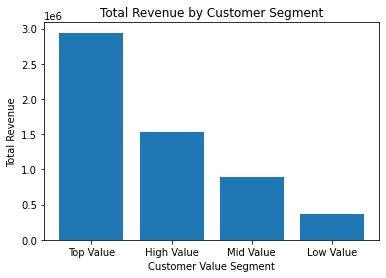

In [123]:
plt.figure()
plt.bar(seg_summary["customer_value_segment"].astype(str), seg_summary["total_revenue"])
plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Value Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

In [124]:
seg_band = (df_customer
            .groupby(["customer_value_segment","price_band"], observed=True)["Revenue_capped"]
            .sum()
            .reset_index())

pivot_seg_band = (seg_band
                  .pivot(index="customer_value_segment", columns="price_band", values="Revenue_capped")
                  .fillna(0))

pivot_seg_band

price_band,0-1,1-3,3-5,5-10,10-20,20-50,50+
customer_value_segment,,,,,,,
Low Value,62056.13,168984.055,65824.175,53354.300,16502.430,1739.235,952.340
Mid Value,137586.85,406594.065,163198.155,142781.925,40517.315,3474.460,1313.250
High Value,243766.93,723609.490,285050.195,214874.700,62201.075,3341.215,1395.600
Top Value,433811.36,1183304.125,625519.655,510738.560,176833.165,10244.135,1551.945


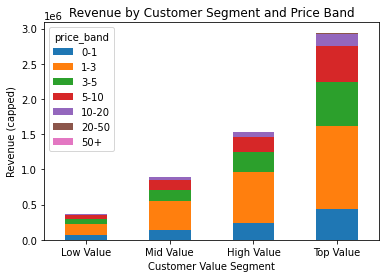

In [125]:
pivot_seg_band.plot(kind="bar", stacked=True)
plt.title("Revenue by Customer Segment and Price Band")
plt.xlabel("Customer Value Segment")
plt.ylabel("Revenue (capped)")
plt.xticks(rotation=0)
plt.show()

- Revenue across customer segments is concentrated in lower and mid price bands, especially the 1–3 and 3–5 ranges. Even high-value customers generate most of their revenue from moderate price levels rather than expensive products.


## 8. Churn Modeling and Threshold Analysis

In [ ]:
df_2011 = df_customer[df_customer["Year"] == 2011].copy()

train_period = df_2011[df_2011["Month"] <= 9]
test_period  = df_2011[df_2011["Month"] > 9]

In [127]:
customer_df = train_period.groupby("Customer_ID").agg({
    "Revenue_capped": "sum",
    "Quantity": "sum",
    "Invoice": "nunique",
    "Price": "mean",
    "qty_rank": "mean",
    "price_rank": "mean",
    "Month": ["max", "nunique"]
})

customer_df.columns = [
    "total_revenue",
    "total_quantity",
    "invoice_count",
    "avg_price",
    "mean_qty_rank",
    "mean_price_rank",
    "last_purchase_month",
    "active_month_count"
]

customer_df = customer_df.reset_index()

In [128]:
test_customers = test_period["Customer_ID"].unique()

customer_df["churn"] = customer_df["Customer_ID"].apply(
    lambda x: 0 if x in test_customers else 1
)

In [129]:
customer_df.isnull().sum()

Customer_ID            0
total_revenue          0
total_quantity         0
invoice_count          0
avg_price              0
mean_qty_rank          0
mean_price_rank        0
last_purchase_month    0
active_month_count     0
churn                  0
dtype: int64

In [130]:
customer_df["log_revenue"] = np.log1p(customer_df["total_revenue"])
customer_df["log_quantity"] = np.log1p(customer_df["total_quantity"])

In [131]:
features = [
    "log_revenue",
    "log_quantity",
    "invoice_count",
    "avg_price",
    "mean_qty_rank",
    "mean_price_rank",
    "last_purchase_month",
    "active_month_count"
]

In [132]:
X = customer_df[features]
y = customer_df["churn"]

In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [134]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [135]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.59      0.64       346
           1       0.64      0.75      0.69       340

    accuracy                           0.67       686
   macro avg       0.67      0.67      0.67       686
weighted avg       0.67      0.67      0.67       686



In [136]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

importance

,Feature,Coefficient
4,mean_qty_rank,0.972452
5,mean_price_rank,0.397876
3,avg_price,0.002485
1,log_quantity,-0.016314
2,invoice_count,-0.099424
6,last_purchase_month,-0.103581
7,active_month_count,-0.249328
0,log_revenue,-0.276273


- Purchase behavior (mean quantity rank) is the strongest driver of churn prediction, indicating that how frequently and how much customers buy is more informative than how much they spend. Revenue alone is not a strong predictor of churn.

In [137]:
y_prob = model.predict_proba(X_test)[:, 1]

In [138]:
import numpy as np
from sklearn.metrics import classification_report

thresholds = [0.40, 0.45, 0.50, 0.55, 0.60]

for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    
    print(f"\nTHRESHOLD = {t}")
    print(classification_report(y_test, y_pred_thresh))


THRESHOLD = 0.4
              precision    recall  f1-score   support

           0       0.74      0.47      0.58       346
           1       0.61      0.83      0.70       340

    accuracy                           0.65       686
   macro avg       0.68      0.65      0.64       686
weighted avg       0.68      0.65      0.64       686


THRESHOLD = 0.45
              precision    recall  f1-score   support

           0       0.72      0.51      0.60       346
           1       0.62      0.80      0.70       340

    accuracy                           0.66       686
   macro avg       0.67      0.66      0.65       686
weighted avg       0.67      0.66      0.65       686


THRESHOLD = 0.5
              precision    recall  f1-score   support

           0       0.70      0.59      0.64       346
           1       0.64      0.75      0.69       340

    accuracy                           0.67       686
   macro avg       0.67      0.67      0.67       686
weighted avg       0.6

In [139]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for t in np.arange(0.35, 0.71, 0.05):
    y_pred_thresh = (y_prob >= t).astype(int)
    
    results.append({
        "Threshold": round(t,2),
        "Accuracy": accuracy_score(y_test, y_pred_thresh),
        "Precision": precision_score(y_test, y_pred_thresh),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1": f1_score(y_test, y_pred_thresh)
    })

pd.DataFrame(results)

,Threshold,Accuracy,Precision,Recall,F1
0,0.35,0.641399,0.592520,0.885294,0.709906
1,0.40,0.651603,0.608602,0.832353,0.703106
2,0.45,0.655977,0.618182,0.800000,0.697436
3,0.50,0.667638,0.640704,0.750000,0.691057
4,0.55,0.673469,0.671598,0.667647,0.669617
5,0.60,0.673469,0.702797,0.591176,0.642173
6,0.65,0.653061,0.723684,0.485294,0.580986
7,0.70,0.612245,0.731250,0.344118,0.468000


## 9. Conclusion


- This analysis demonstrates how transactional data can be transformed into actionable insights, enabling businesses to understand customer value, predict churn, and design targeted retention strategies.

- Sales performance is primarily driven by purchase volume rather than high pricing, as most revenue is generated from low to mid price ranges across all customer segments.

- Customer segmentation highlights that Top Value customers contribute more than half of total revenue, making them critical for business sustainability.

- The churn prediction model achieved moderate but practical performance, with strong ability to identify at-risk customers based on behavioral features.

- Threshold optimization demonstrated that model outputs can be adapted to different business strategies, allowing companies to prioritize either broader churn detection or more precise targeting depending on operational goals.

- Overall, combining customer segmentation with churn prediction provides a strong foundation for targeted retention strategies and revenue optimization.